## Optional: Step 6a of stellar halo pipeline

This notebook is designed to allow the user to check the results of steps 1-5 of the stellar halo pipeline and, in combination with FixHostIDs, amend the allhalostardata hdf5 file as needed. The general idea is to visually inspect all of the star particles that have been assigned to a particular host and either make sure that that assignment makes sense or reassign them. Incorrect assignments often happen during mergers, particularly if the halo finder loses track of the smaller ha
lo before it ceases star formation. I typically use it for at least the following:

1. Attempt to identify the hosts of any star particles that didn't get assigned one during the earlier steps of the pipeline (i.e., those with StepIndex_0 as a host_ID in the allhalostardata hdf5 file). These are most common in the very first snapshot and, in that case, typically formed in halos that started merging before the first snapshot was saved. However, it's typically clear which ones should go together, because there will be individual clumps. I save the IDs of star particles that appear to go together and give them an id of Step_-n (n=1,2,3...) to make it clear that these particles formed in the same location, but do not belong to a halo that can be traced backwards.

2. Check that star particles assigned to the same halo actually make up a coherent structure. I typically start by visualizing the particles belonging to each host_ID at the snapshot when that halo was last identified to make sure that this is a single entity. If the halo has already started to disrupt, I will back up until I find the last snapshot where it was a coherent structure and make sure all of the star particles assigned to it make sense. If necessary, I will go through each snapshot and make sure that each star particle that formed between this snapshot and the last one that was assigned to this halo actually appear to have formed there. Even amiga sometimes gets confused during mergers and will assign star particles to the wrong host.

3. Check that every star particle that is assigned to the central galaxy is actually an in situ star particle. This is really an extension of 2, but for the main halo I always walk through every single snapshot and just look at the star particles that have formed since the last snapshot and have been assigned to the main halo. It is fairly common to see star particles that clearly formed in a disrupting satellite get assigned to the host because the halo finder has lost track of the satellite.

If you end up needing to reassign quite a few star particles, it may be helpful to hop over to FixHostIDs to do so and then come back here and load in your updated allhalostardata hdf5 file.

In [1]:
# Loads in the path to the database and the simulation files for either the MM or Marvel runs,
#.   for both quirm and emu
%matplotlib inline
import os
import socket
import tangos
hostname = socket.gethostname()
if 'emu' in hostname:
    #os.environ['TANGOS_SIMULATION_FOLDER'] = '/home/ns1917/tangos_sims/storm.4096g5HbwK1BH_bn/'
    #os.environ['TANGOS_DB_CONNECTION'] = '/home/ns1917/Databases/Marvel_BN_N10.db'

    # For Romulus zooms
    simpath = '/data/REPOSITORY/romulus_zooms'
    os.environ['TANGOS_SIMULATION_FOLDER'] = simpath
    # os.environ['TANGOS_DB_CONNECTION'] = simpath + 'rom25_dwarf_zooms.db'
    tangos.core.init_db(simpath + '/rom25_dwarf_zooms.db')

    # os.environ['TANGOS_DB_CONNECTION'] = '/home/ns1917/pynbody/Tangos/Marvel_BN_N10.db'
    
    #os.chdir('/home/ns1917/pynbody/AnnaWright_startrace/')
    os.chdir('/home/christenc//Code/python/NithunSelva_startrace/pynbody/AnnaWright_startrace/')
else: # grinnell
    os.environ['TANGOS_SIMULATION_FOLDER'] = '/home/selvani/MAP/Sims/cptmarvel.cosmo25cmb/cptmarvel.cosmo25cmb.4096g5HbwK1BH/'
    # os.environ['TANGOS_DB_CONNECTION'] = '/home/selvani/MAP/Data/Marvel_BN_N10.db'
    os.environ['TANGOS_DB_CONNECTION'] = '/home/selvani/MAP/pynbody/Tangos/Marvel_BN_N10.db'
    os.chdir('/home/selvani/MAP/pynbody/AnnaWright_startrace/')

import pynbody
import numpy as np
import h5py
import math
import tangos as db
import matplotlib.pyplot as plt
from IPython.display import Audio
import glob
from pynbody.array import SimArray
import IonUtils

In [2]:
def HighlightParticles(s, cen, rad=2, projax='x', show_hs=True, show_tlim=True, ret='relstars',
                      savefig=False, thread=True, haloplot=True):
    '''
    Primary workhorse of this notebook
    Creates two figures:
    1. a gas density image using all particles within rad kpc of cen and projected along the projax axis.
       Any stars that formed during the relevant time period (i.e., between tslim and st) and were assigned
       to the relevant halo(s) (relhostid) will be shown as green dots. If show_hs=True, other star particles in this
       region will also be shown in cyan. This often helps to highlight when incorrect halo assignments have been made
       (e.g., if a bunch of green stars are in a separate clump away from the other green stars and are clearly centered
       on a clump of cyan stars). If savefig=True, this will be saved.
    2. a bar graph showing the numbers of stars in this region that have been assigned to different hosts - another way to 
       potentially identify incorrect halo assignments. This bit will also print out every unique host ID with at least one
       star in this region assigned to it so and the number of stars assigned to it.
    If ret='relstars',returns the list of stars in this region that formed between tslim and st and were assigned to relhostid so that, 1) You
    can check these off the list and look for any errant particles that formed during this time and were assigned to this host
    but are not in this region and 2) if you want to reassign them with FixHostID, you can save them to a numpy file and do so.
    If ret is set to anything else, it will return the full list of stars in the region.
    The "thread" argument is purely for debugging. Set this to False to debug if pynbody barfs. Most often, what you need to
    do is increase the size of the region you're imaging because there are too few gas particles in your currently specified region.
    If show_tlim = True, will highlight the star particles that formed since lowlim_select and uplim, which are the time limits you used to select relevant particles in the first place. This is just a sanity check to make sure you're not missing any stars that formed during this time period but were assigned to a different halo or are outside this region.
    '''
    import matplotlib.patches as mpatches

    sp = s[pynbody.filt.Sphere(SimArray([rad], "kpc"), cen)].load_copy() # only show particles in the specified sphere
    sp.physical_units()
    ns = len(sp.s)
    if ns > 0:  # make sure the sphere actually contains some stars
        # Construct star and gas image
        rel2 = np.isin(sp.s['iord'], pids)
        rel_tlim = np.isin(sp.s['iord'], pids_tlim)
        print(len(sp.s['iord'][rel2]), 'relevant stars found')
        tx = None
        sp['pos'] -= cen
        x_title = 'X (kpc)' # Looking down the x-axis
        y_title = 'Y (kpc)'       
        if projax == 'y':
            sp.rotate_x(90)
            x_title = 'X (kpc)'
            y_title = 'Z (kpc)'
        elif projax == 'x':
            sp.rotate_y(90)
            x_title = 'Z (kpc)'
            y_title = 'Y (kpc)'
        elif projax == 'faceon':
            tx = pynbody.analysis.angmom.faceon(sp)
        elif projax == 'sideon':
            tx = pynbody.analysis.angmom.sideon(sp)
        pynbody.plot.sph.image(
            sp.g, qty="rho", units="Msol pc**-2", width=2*rad,
            vmin=10**-3, vmax=10**3, cmap="plasma", threaded=thread
        )
        if show_hs:
            plt.plot(
                sp.s['pos'][:, 0], sp.s['pos'][:, 1],
                markersize=1.0, color='grey', marker='o', alpha=0.1, linestyle='none')
        plt.plot(
            sp.s['pos'][rel2][:, 0], sp.s['pos'][rel2][:, 1],
            markersize=2.0, color='green', marker='o', alpha=0.5, linestyle='none', label = 'Relevant Stars')
        if show_tlim and np.sum(rel_tlim) > 0:
            plt.plot(
                sp.s['pos'][rel_tlim][:, 0], sp.s['pos'][rel_tlim][:, 1],
                markersize=2.0, color='cyan', marker='o', alpha=0.5, linestyle='none', label = 'Stars Formed Since Time Limit')
        if haloplot:
            # --- HALO CIRCLE OVERLAY ---
            all_halos = db.get_timestep(ss_dir+'/%'+str(st).zfill(4)).halos.all()
            all_halos = [halo for halo in all_halos if halo.NStar > 0]
            # cut by location
            halos = []
            for halo in all_halos:
                try:
                    if np.linalg.norm(np.array(halo['shrink_center']) - cen) < rad:
                        halos.append(halo)
                except Exception as e:
                    print(f"Could not process halo {halo.halo_number}: {e}")
            print('Found', len(halos), 'halos with stars')
            if halos is not None:
                print(halos)
                for halo in halos:
                    try:
                        # Get halo center and Rvir, shift to plotting coordinates
                        rvir = float(halo['Rvir'])  # in kpc
                        # Get halo center and shift to plotting coordinates
                        hcen = np.array(halo['shrink_center']) - cen

                        # Apply the SAME rotation that was applied to particles
                        if projax == 'y':
                            # Apply 90-degree rotation around x-axis
                            hcen = np.array([hcen[0], -hcen[2], hcen[1]])
                        elif projax == 'z':
                            # Apply 90-degree rotation around y-axis  
                            hcen = np.array([hcen[2], hcen[1], -hcen[0]])
                        elif projax == 'faceon' or projax == 'sideon':
                            if tx is not None and hasattr(tx, 'matrix'):
                                # Apply the transformation matrix to the halo center
                                transform_matrix = tx.matrix
                                print('Applying transformation matrix')
                                hcen = np.dot(transform_matrix, hcen)

                        # Now project to 2D (always use x,y after proper rotation)
                        x, y = hcen[0], hcen[1]

                        circle = mpatches.Circle(
                            (x, y), rvir, edgecolor='white', facecolor='none', lw=0.75, alpha=0.7)
                        plt.gca().add_patch(circle)
                    except Exception as e:
                        print(f"Could not plot halo {halo.halo_number}: {e}")

        plt.xlabel(x_title)
        plt.ylabel(y_title)
        if savefig:
            plt.savefig(odir + 'stars_' + str(tslim).zfill(4) + '_' + str(st).zfill(4) +
                        '_' + projax + '.png', dpi=150)
        plt.show()

        # Construct bar plot
        spstars = sp.s['iord']
        relhalo = np.isin(partids, spstars)
        reltlim = np.isin(pids_tlim, spstars) # which stars formed within the time window?
        cat = []
        num = []
        num_tlim = []
        for hival in np.unique(hostids[relhalo]):
            cat.append(hival)
            ct = np.count_nonzero(hostids[relhalo] == hival)
            # Get particle IDs for this host and find which sphere stars match
            host_pids = partids[hostids == hival]
            in_sphere_with_host = np.isin(sp.s['iord'], host_pids)
            ct_tlim = np.count_nonzero(in_sphere_with_host & (sp.s['tform'] >= lowlim_select) & (sp.s['tform'] <= uplim))
            print(hival, ct, ct_tlim)
            num.append(ct)
            num_tlim.append(ct_tlim)
        plt.figure(figsize=(12, 9))
        plt.bar(cat, num, label='All Stars')
        plt.bar(cat, num_tlim, label='Within Time Limit', alpha = 0.7)
        plt.xlabel('Host Halo ID')
        plt.ylabel('Number of Stars')
        plt.legend()
        plt.show()
        bb = cat[np.argmax(num)]
        print('likely host:', bb)  # host with the most stars in this region
    else:
        print('No stars in this sphere!')
        rel2 = np.array([])
    if ret == 'relstars':
        return sp.s['iord'][rel2]
    else:
        return sp.s['iord']


In [3]:
def HighlightParticlesMultiProjection(s, cen, rad=2, show_hs=True, ret='relstars',
                                    savefig=False, thread=True, haloplot=True, figsize=(24, 6), caption=None, overwrite=True):
    '''
    Creates x, y, and z projections and a host assignment bar plot in a single 1x4 figure.
    
    Parameters:
    -----------
    s : pynbody snapshot
        The simulation snapshot
    cen : array-like
        Center position for the sphere [x, y, z] in kpc
    rad : float, default=2
        Radius of the sphere in kpc
    show_hs : bool, default=True
        Whether to show other star particles in cyan
    ret : str, default='relstars'
        Return type - 'relstars' for relevant stars only, else all stars
    savefig : bool, default=False
        Whether to save the figure
    thread : bool, default=True
        Whether to use threading for image generation
    haloplot : bool, default=True
        Whether to overlay halo circles
    figsize : tuple, default=(24, 6)
        Figure size for the 1x4 subplot
    caption : str, optional
        Caption to add to the figure

    Returns:
    --------
    list : Star particle IDs based on ret parameter
    '''
    import os
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches
    from pynbody.array import SimArray
    
    if savefig:
        # Ensure the output directory exists
        save_dir = os.path.join(odir, 'plots')
        os.makedirs(save_dir, exist_ok=True)
        # Use a more descriptive filename
        save_path = os.path.join(save_dir, f"stars_{halo_id}_{caption}_projections_HI.png")
        print(save_path)
        if os.path.exists(save_path) and not overwrite:
            print(f"File {save_path} already exists. Skipping.")
            return 1

    # Create the sphere and load data
    sp = s[pynbody.filt.Sphere(SimArray([rad], "kpc"), cen)].load_copy()
    sp.physical_units()
    if len(sp.g) > pynbody.config['sph']['smooth-particles']:
        print('Calculatinggas mass...')
        IonUtils.calculate_gas_mass(sp)
        print('Calculating gas densities...')
        IonUtils.calculate_gas_rhos(sp)
    ns = len(sp.s)
    
    if ns > 0:
        # Identify relevant stars
        rel2 = np.isin(sp.s['iord'], pids)
        print(f"{len(sp.s['iord'][rel2])} relevant stars found")
        
        # --- Calculate data for bar plot ahead of time ---
        spstars = sp.s['iord']
        relhalo = np.isin(partids, spstars)
        cat = []
        num = []
        if np.any(relhalo):
            unique_hosts, counts = np.unique(hostids[relhalo], return_counts=True)
            for hival, ct in zip(unique_hosts, counts):
                cat.append(str(hival)) # Ensure category labels are strings
                num.append(ct)
            
            if cat:
                bb = cat[np.argmax(num)]
                print('Likely host:', bb)
        
        # Store original positions before any modifications
        original_pos = sp['pos'].copy()
        
        # Create figure with 1x4 subplots
        fig, axes = plt.subplots(1, 4, figsize=figsize)
        projections = ['x', 'y', 'z']
        titles = ['X Projection (Y-Z plane)', 'Y Projection (X-Z plane)', 'Z Projection (X-Y plane)']
        
        # Add the main caption (suptitle) if provided
        if caption:
            fig.suptitle('Halo {}'.format(caption), fontsize=16)

        if haloplot:
            # --- HALO CIRCLE OVERLAY ---
            all_halos = db.get_timestep(ss_dir+'/%'+str(st).zfill(4)).halos.all()
            all_halos = [halo for halo in all_halos if halo.NStar > 0]
            # cut by location
            halos = []
            for halo in all_halos:
                try:
                    if np.linalg.norm(np.array(halo['shrink_center']) - cen) < rad:
                        halos.append(halo)
                except Exception as e:
                    print(f"Could not process halo {halo.halo_number}: {e}")
            print('Found', len(halos), 'halos with stars')
            if halos is not None:
                # distinguishable_colors = [
                #         '#e6194B', '#3cb44b', '#ffe119', '#4363d8', '#f58231', 
                #         '#911eb4', '#42d4f4', '#f032e6', '#bfef45', '#fabed4', 
                #         '#469990', '#dcbeff', '#9A6324', '#fffac8', '#800000', 
                #         '#aaffc3', '#808000', '#ffd8b1', '#000075', '#a9a9a9'
                # ]
                halo_colors = {}
                cmap = plt.get_cmap('Set3', len(halos))
                for i, halo in enumerate(halos):
                    halo_colors[halo.halo_number] = cmap(i)
                print(halos)

        # --- Plotting the three projections on the first 3 axes ---
        for i, (ax, projax, title) in enumerate(zip(axes[:3], projections, titles)):
            # Reset positions and apply centering for each projection
            sp['pos'] = original_pos.copy()
            sp['pos'] -= cen
            
            # Apply rotations for different projections
            if projax == 'y':
                sp.rotate_x(90)
            elif projax == 'z':
                sp.rotate_y(90)
            
            # Create gas density image
            if len(sp.g) > pynbody.config['sph']['smooth-particles']:
                qty_gas = "HI_rho"
            else:
                qty_gas = "rho"
                print("Not enough gas particles to plot HI density. Plotting total density instead.")
            pynbody.plot.sph.image(
                sp.gas, qty=qty_gas, units="Msol pc**-2", width=2*rad,
                vmin=10**-3, vmax=10**3, cmap="plasma", threaded=thread,
                axes=ax
            )
            
            # Plot star particles
            if show_hs:
                ax.plot(
                    sp.s['pos'][:, 0], sp.s['pos'][:, 1],
                    markersize=1.0, color='cyan', marker='o', alpha=0.1, linestyle='none',
                    label='Other stars'
                )
            
            ax.plot(
                sp.s['pos'][rel2][:, 0], sp.s['pos'][rel2][:, 1],
                markersize=2.0, color='green', marker='o', alpha=0.25, linestyle='none',
                label='Relevant stars'
            )
            
            # Add halo circles if requested
            if haloplot:
                if halos is not None:
                    for halo in halos:
                        try:
                            # Get halo center and Rvir, shift to plotting coordinates
                            try:
                                rvir = float(halo['Rvir'])  # in kpc
                            except Exception as e:
                                rvir = float(halo['max_radius'])
                            # Get halo center and shift to plotting coordinates
                            hcen = np.array(halo['shrink_center']) - cen

                            # Apply the SAME rotation that was applied to particles
                            if projax == 'y':
                                # Apply 90-degree rotation around x-axis
                                hcen = np.array([hcen[0], -hcen[2], hcen[1]])
                            elif projax == 'z':
                                # Apply 90-degree rotation around y-axis  
                                hcen = np.array([hcen[2], hcen[1], -hcen[0]])

                            # Now project to 2D (always use x,y after proper rotation)
                            x, y = hcen[0], hcen[1]

                            circle = mpatches.Circle(
                                (x, y), rvir, edgecolor=halo_colors[halo.halo_number], facecolor='none', lw=0.75, alpha=1,
                                label=f'Halo {halo.halo_number}'
                            )
                            ax.add_patch(circle)
                            circle.set_clip_path(ax.patch)
                        except Exception as e:
                            print(f"Could not plot halo {halo.halo_number}: {e}")

            
            # Set title and labels
            ax.set_title(title, fontsize=12)
            
            # Add legend to first subplot
            if i == 0 and (show_hs or len(sp.s['iord'][rel2]) > 0):
                ax.legend(loc='upper right', fontsize=8)

        # --- Construct bar plot on the 4th subplot ---
        ax4 = axes[3]
        if len(cat) > 0:
            ax4.bar(cat, num)
            ax4.set_ylabel('Number of Stars')
            ax4.set_title('Star Particle Host Assignments')
            ax4.tick_params(axis='x', labelrotation=90, labelsize=8)
        else:
            ax4.text(0.5, 0.5, 'No host assignments found', ha='center', va='center', transform=ax4.transAxes)
            ax4.set_title('Star Particle Host Assignments')
            ax4.set_xticks([])
            ax4.set_yticks([])

        plt.tight_layout()
        
        # Adjust layout if a caption is present to prevent it from overlapping
        if caption:
            plt.subplots_adjust(top=0.88)

        if savefig:
            # Ensure the output directory exists
            save_dir = os.path.join(odir, 'plots')
            os.makedirs(save_dir, exist_ok=True)
            # Use a more descriptive filename
            if consolidated:
                filename = f"stars_{halo_id}_{caption}_projections_HI_consolidated.png"
            else:
                filename = f"stars_{halo_id}_{caption}_projections_HI.png"
            save_path = os.path.join(save_dir, filename)
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
            print(f"Figure saved to {save_path}")
        plt.show()
        
    else:
        print('No stars in this sphere!')
        rel2 = np.array([])
        return np.array([])
    
    if ret == 'relstars':
        return sp.s['iord'][rel2]
    else:
        return sp.s['iord']


In [4]:
def get_halo(snapshot, halo_number):
    '''
    Retrieve a specific halo object from the Tangos database for a given snapshot.

    Parameters
    ----------
    snapshot : int or str
        The snapshot number (e.g., 384). Used to construct the Tangos timestep path
        as "{ss_dir}/%{snapshot}".
    halo_number : int
        The halo number (as assigned by the halo finder) to retrieve.

    Returns
    -------
    tangos.Halo or None
        The first halo object matching halo_number at the specified timestep,
        or None if no match is found.
    '''
    ts = db.get_timestep(f"{ss_dir}/%{snapshot}")
    # print(f"Retrieved timestep: {ts}")
    return ts.halos.filter_by(halo_number=int(halo_number)).first()


In [5]:
consolidated = True # True means using the files which list the last halo prior to merger
mm = True # True if using the MM simulations, False if using the Marvel sims

if 'emu' in hostname:
    if mm:
        simpath = '/data/REPOSITORY/romulus_zooms/' # MM simulations
    else:
        simpath = '/home/ns1917/tangos_sims/' # Marvel, BN halos
        consolidated = False # Marvel sims don't have consolidated files, so set this to False
    
    if consolidated: # Consolidated should only apply to mm runs
        idir = "/home/christenc/Code/Datafiles/stellar_halos/" # where *_allhalostardata_consolidated2.h5 files are located
        starfileext = "allhalostardata_consolidated2"
    else:
        idir = "/home/christenc/dwarf_stellar_halos/" # where the "*_allhalostardata.h5" files are located
        starfileext = "allhalostardata"
    odir = "/home/christenc/Code/python/NithunSelva_startrace/pynbody/stellarhalo_trace_aw/" # where you want to save outputs
    #odir = "/home/ns1917/pynbody/stellarhalo_trace_aw/"  
else:
    simpath = '/home/selvani/MAP/Sims/cptmarvel.cosmo25cmb/cptmarvel.cosmo25cmb.4096g5HbwK1BH/'
    odir = "/home/selvani/MAP/pynbody/stellarhalo_trace_aw/"
    idir = odir

# MM sims
if mm:
    halo_id = 'r615'
    ss_dir = halo_id + '.romulus25.3072g1HsbBH'
    sims = halo_id
    idir = idir + '/' + halo_id
    sim_base = simpath + ss_dir + '/'
    #step = '.000288'
    #ss_z0 = sim_base + ss_dir + step
else:
    # sims = 'cptmarvel.cosmo25cmb.4096g5HbwK1BH'
    sims = 'rogue.cosmo25cmb.4096g5HbwK1BH'
    # ss_dir = 'cptmarvel.4096g5HbwK1BH_bn'
    ss_dir = 'rogue.4096g5HbwK1BH_bn'
    sim_base = simpath + ss_dir + '/'
    #ss_z0 = sim_base + sims + '.004096'

sim = db.get_simulation(ss_dir)
# odir = '/Users/Anna/Research/Outputs/M33Analogs/MM/'+halo+'/'
# simpath = '/Volumes/Audiobooks/RomZooms/'
sim.timesteps

[<TimeStep 'r615.romulus25.3072g1HsbBH/r615.romulus25.3072g1HsbBH.000096/r615.romulus25.3072g1HsbBH.000096' z=12.73 t=0.34 Gyr>,
 <TimeStep 'r615.romulus25.3072g1HsbBH/r615.romulus25.3072g1HsbBH.000192/r615.romulus25.3072g1HsbBH.000192' z=7.80 t=0.66 Gyr>,
 <TimeStep 'r615.romulus25.3072g1HsbBH/r615.romulus25.3072g1HsbBH.000288/r615.romulus25.3072g1HsbBH.000288' z=5.75 t=0.99 Gyr>,
 <TimeStep 'r615.romulus25.3072g1HsbBH/r615.romulus25.3072g1HsbBH.000384/r615.romulus25.3072g1HsbBH.000384' z=4.58 t=1.31 Gyr>,
 <TimeStep 'r615.romulus25.3072g1HsbBH/r615.romulus25.3072g1HsbBH.000480/r615.romulus25.3072g1HsbBH.000480' z=3.82 t=1.63 Gyr>,
 <TimeStep 'r615.romulus25.3072g1HsbBH/r615.romulus25.3072g1HsbBH.000576/r615.romulus25.3072g1HsbBH.000576' z=3.27 t=1.96 Gyr>,
 <TimeStep 'r615.romulus25.3072g1HsbBH/r615.romulus25.3072g1HsbBH.000672/r615.romulus25.3072g1HsbBH.000672' z=2.85 t=2.28 Gyr>,
 <TimeStep 'r615.romulus25.3072g1HsbBH/r615.romulus25.3072g1HsbBH.000768/r615.romulus25.3072g1HsbBH.000

In [6]:
# Read in your data
print("Halo file: ", idir+'/'+sims+'_'+starfileext+'.h5')
with h5py.File(idir+'/'+sims+'_'+starfileext+'.h5','r') as f:
    hostids = f['host_IDs'].asstr()[:] # unique host IDs
    partids = f['particle_IDs'][:] # iords
    pct = f['particle_creation_times'][:] # formation times
    ph = f['particle_hosts'][:] # local host IDs (i.e., host at formation time)
    pp = f['particle_positions'][:] # position at formation time
    tsloc = f['timestep_location'][:] # snapshot where star particle first appears
uIDs = np.unique(hostids)
print('Unique host IDs: ', uIDs)

Halo file:  /home/christenc/Code/Datafiles/stellar_halos//r615/r615_allhalostardata_consolidated2.h5
Unique host IDs:  ['0192_-4' '0192_2' '0192_23' '0192_38' '0192_39' '0192_55' '0192_6'
 '0288_189' '0384_152' '0384_28' '0384_7' '0480_42' '0480_66' '1056_106'
 '1056_43' '1248_27' '1440_13' '1728_3' '2016_10' '3744_24' '4032_2'
 '4096_1' '4096_12' '4096_2' '4096_204' '4096_3' '4096_4' '4096_521']


In [ ]:
# Allows the user to select a specific halo (relhostid ), the timestep to visulize it at (st),
#.   the first snapshot relevant stars could have formed at (tslim), and the halo to center on at that snapshot(ishalo)

#,'480_2','0384_-1','0384_-2'
relhostid = np.array(['0192_6']) #,'4096_1'])#'1152_5']) #,'0192_-1','0223_13']) #, '1344_02']) # Which star particle host_IDs do you want to see? This can be a single host_ID or a list
# For instance, if you wanted to see all star particles that weren't assigned a host, you could do the below
# relhostid = []
# for i in range (0,len(sim.timesteps)):
#     relhostid.append(str(i).zfill(4)+'_0')
# relhostid = np.array(relhostid)
# print('relhostid = ', relhostid)

# 136, 576
st = '3648' #. '192' '273' '288' '345' '384' '0345' '0672' #'480' #  '454' '0576' # Which snapshot do you want to visualize these star particles at?
tslim = 0 # What is the earliest snapshot that you want the star particles to have formed at?
#tslim = st-96 # This is the standard MM spacing, so this would give you any star particles that formed since last snapshot
tslim_select = int(st)-96 # tslim_select can be used to trim the list of stars in the region to those formed more recently than this
#tslim_select = 2112
ishalo = 0 # Which halo do you want to center on? If this is 0, we will center on the first star particles with relhostid

# This tells you the index of the snapshot you're looking at in the tangos database.
#.   It is used in later steps to limit the list of star particles to those that formed since a time 
#    and to load in the correct snapshot for visualization.
dbind_lim = 0
for ctr,ts in enumerate(sim.timesteps):
    if str(st).zfill(6) in str(ts):
        dbind = ctr
    if str(tslim).zfill(6) in str(ts):
        dbind_lim = ctr
    if str(tslim_select).zfill(6) in str(ts):
        dbind_lim_select = ctr
print ('Database index: ',dbind)

Database index:  9


In [8]:
# Calculate the times corresponding to the limits you specified earlier and ID the star particles that formed
# between these times and were assigned to relhostid
uplim = sim[dbind].time_gyr
if tslim>0:
    lowlim = sim[dbind_lim].time_gyr-0.001
elif tslim == 0:
    lowlim = 0
else:
    print ('Please rethink your lowlim value. It does not make sense.')

# This step determines a time to be used later to select all stars in the region formed after the given tiem
if tslim_select>0:
    lowlim_select = sim[dbind_lim_select].time_gyr-0.001
elif tslim_select == 0:
    lowlim_select = 0
else:
    print ('Please rethink your lowlim value. It does not make sense.')


# Selects stars that belong to the halo(s) you're inspecting, and formed within the time window between the 
#     two snapshots you specified
pids = partids[(np.isin(hostids,relhostid)) & (pct>lowlim) & (pct<uplim)]

print ('Relevant particles:',len(pids)) # How many star particles will actually be highlighted?

# Selects all stars that formed within the time window between the two snapshots you specified, regardless of host assignment. 
pids_tlim = partids[(pct>lowlim_select) & (pct<uplim)]

# Selects all stars that were assigned to the halo(s) you're inspecting, regardless of formation time. 
pids_halo = partids[np.isin(hostids,relhostid)]

Relevant particles: 82704


In [9]:
len(partids[(np.isin(hostids,relhostid))])

223005

In [10]:
np.unique(hostids[np.isin(partids, pids)]) # Which unique host IDs are represented by the star particles that formed within the time window and were assigned to the halo(s) you're inspecting?

array(['1728_3'], dtype=object)

###  Single Snapshot Inspection ("Old" section)

Loads the snapshot with pynbody.
Determines the center (roughcen) either from Tangos (shrink_center) or median particle positions.
Cells for automated spike-finding (histogram peaks → cluster centers) to locate spatially separated groups of star particles.

In [11]:
if mm:
    fpath = sim_base + ss_dir + '.' +str(st).zfill(6) + '/' + ss_dir + '.' +str(st).zfill(6)
else:
    fpath = sim_base + sims + '.' +str(st).zfill(6)
print(fpath)
s = pynbody.load(fpath)
s.physical_units()
h = s.halos(halo_numbers='v1')

# all_halos = db.get_timestep(ss_dir+'/%'+str(st)).halos.all()
# halos = [halo for halo in all_halos if halo.NStar > 0]
# print('Found', len(halos), 'halos with stars')
# print(halos[1].halo_number)

relstars = np.isin(s.s['iord'],pids) # which relevant stars actually exist at this snapshot?
# "relevant stars" are those that formed between tslim and st and were assigned to relhostid, but not all of these will necessarily exist at this snapshot (e.g., if they formed after this snapshot or if they were kicked out of the halo and are now in a different region of the simulation). This variable is used to determine which star particles to highlight in the visualization.
print("Number of relevant stars in this snapshot:", np.count_nonzero(relstars))

stars_tlim = np.isin(s.s['iord'],pids_tlim) # which stars formed within the time window?
stars_halo = np.isin(s.s['iord'],pids_halo) # which stars were assigned to the halo(s) you're inspecting, regardless of formation time

/data/REPOSITORY/romulus_zooms/r615.romulus25.3072g1HsbBH/r615.romulus25.3072g1HsbBH.000960/r615.romulus25.3072g1HsbBH.000960


pynbody.halo : An error occurred while reading substructure file. Falling back to using the halo info.


Number of relevant stars in this snapshot: 82704


In [12]:
# Center on relevant area

"""
if ishalo == 0:
    roughcen = s.s['pos'][relstars][0] # if the user set ishalo to 0, we'll just center on the first star particle with relhostid
else:
    try:
        halo = get_halo(st, ishalo)
        roughcen = halo['shrink_center']
    except:
        roughcen = pynbody.analysis.halo.shrink_sphere_center(h[ishalo])
roughcen
"""

if ishalo == 0:
    roughcen = np.median(s.s['pos'][relstars],axis=0) # center on first relevant star particle
else:
    hind = sim[dbind][ishalo].halo_number # center on median position of particles in ishalo
    hhindpos = h[hind]['pos']
    # print('hhindpos = ', hhindpos)
    roughcen = np.median(hhindpos,axis=0)
roughcen

# halo = db.get_timestep(ss_dir+'/%'+str(st)).halos.all()[ishalo]
# roughcen = halo['shrink_center'] # Get the center of the halo we're looking at

# roughcen += (-12.5, -17, -5)
# roughcen += (-2.5, -0.5, -4)
# roughcen += (-0.5,-3,2.5)
# roughcen += (3,-1.25,4.8)
# roughcen += (5,-5,13)

SimArray([-180.94366126,  269.21251848, -472.8377152 ], 'kpc')

Looking for:  82704
82402 relevant stars found


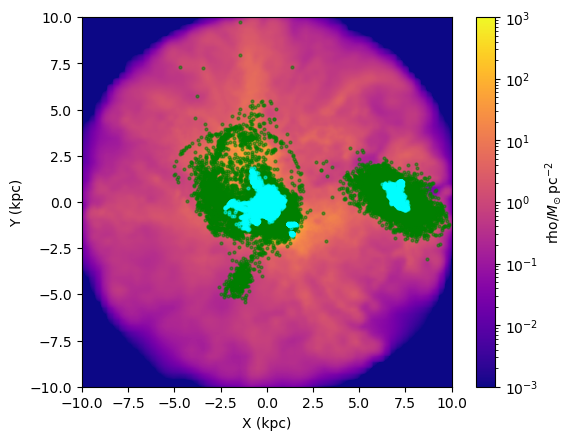

1056_43 3 0
1728_3 82402 27141


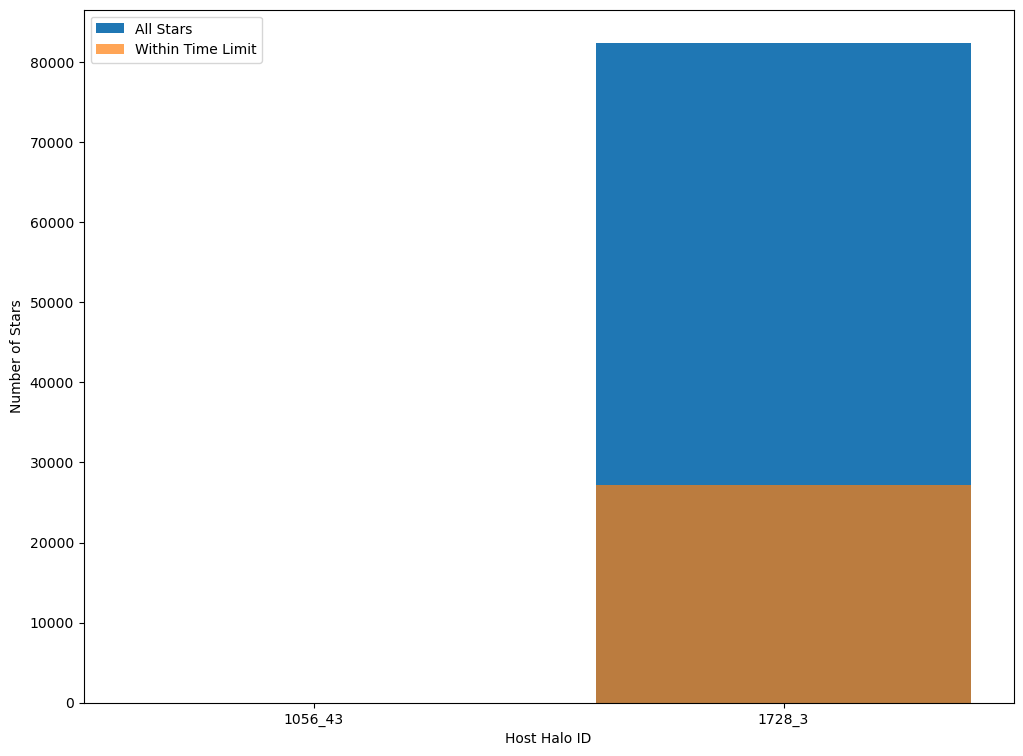

likely host: 1728_3


In [ ]:
rad = 7 # How big of a region do you want to look at (in kpc)?
print ('Looking for: ', len(pids)) # Full number of relevant star particles in this snapshot.
                                   # Make sure you actually find all of them!
# Green points are stars that are in the select halo and formed within the selected time period
fst = HighlightParticles(s,roughcen,rad=rad,projax='z',haloplot=False, show_hs=True, ret='relstars') # Have our first look 

In [20]:
# Determine a reasonable area based on the distribuition of star particles in this region

# This is the maximum distance of any relevant star particle from the rough center. You can use this to help you decide how big of a region to look at.
valout = np.max(np.power(np.sum(np.power(s.s['pos'][relstars]-roughcen, 2), axis=1), 1/2))
print(valout)

13.788666451965574


### Automate spike finding
#### This portion of the code is useful for dividing halos into smaller ones

In [21]:
# Histogram of x offsets (relative to rough center) in ~50 pc bins

# Histogram of x offsets (relative to rough center) in ~50 pc bins

axes_id = 0 # 0:'x', 1:'y', or 2:'z' - which axis do you want to look along to determine a more precise center? 
#.  This should be the axis along which the distribution of star particles is most clearly peaked. You can use the first few plots to help you decide this.
axes = ['x', 'y', 'z']
pos1d_rel = np.asarray((s.s[axes[axes_id]][relstars] - roughcen[axes_id]).in_units('kpc'))
binwidth = 0.1 # in kpc
counts, pos1d_rel_edges = np.histogram(
    pos1d_rel,
    range=(-rad, rad),
    bins=int(np.ceil((2 * rad) / binwidth))
)
pos1d = pos1d_rel_edges[:-1] + np.diff(pos1d_rel_edges) / 2

# For comparison, also graph the histogram of all the star particles in this region
pos1d_all = np.asarray((s.s[axes[axes_id]] - roughcen[axes_id]).in_units('kpc'))
counts_all, pos1d_all_edges = np.histogram(
    pos1d_all,
    range=(-rad, rad),
    bins=int(np.ceil((2 * rad) / binwidth))
)

# Graph the distribution of revently formed stars
pos1d_tlim = np.asarray((s.s[axes[axes_id]][stars_tlim] - roughcen[axes_id]).in_units('kpc'))
counts_tlim, pos1d_tlim_edges = np.histogram(
    pos1d_tlim,
    range=(-rad, rad),
    bins=int(np.ceil((2 * rad) / binwidth))
)

# Graph the distribution of stars assigned to the selected halo
pos1d_halo = np.asarray((s.s[axes[axes_id]][stars_halo] - roughcen[axes_id]).in_units('kpc'))
counts_halo, pos1d_rel_edges = np.histogram(
    pos1d_halo,
    range=(-rad, rad),
    bins=int(np.ceil((2 * rad) / binwidth))
)


# Identify the peaks in the relevant star particles distribution and use this to determine a more precise center along the axis you're looking along. 
import scipy.signal
peak_arr = counts_all # Array of counts to use to identify peaks
peaks = scipy.signal.find_peaks(peak_arr, height=max(counts_all)*1e-1) # find peaks in the histogram with a height threshold to avoid noise

final_axes = pos1d[peaks[0]] + roughcen[axes_id]

# Sort by peak height (descending order)
sort_order = np.argsort(peaks[1]['peak_heights'])[::-1]
final_axes = final_axes[sort_order]
peak_indices = peaks[0][sort_order]
peak_properties = {key: peaks[1][key][sort_order] for key in peaks[1].keys()}

print('final_axes = ', final_axes)


final_axes =  [-181.29366126 -173.99366126 -180.69366126]


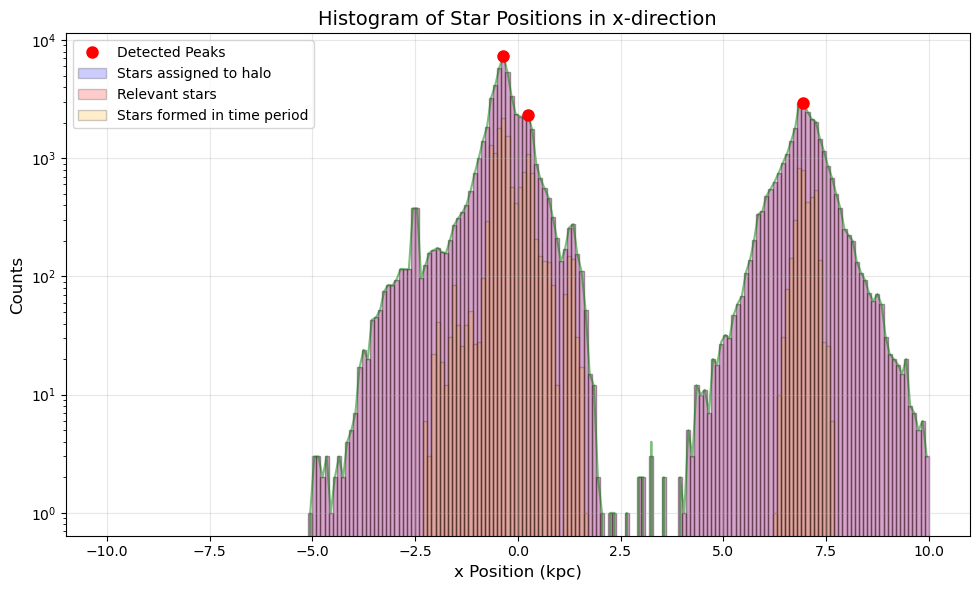

In [22]:
import matplotlib.pyplot as plt

# Plot histogram of counts vs x_edges
plt.figure(figsize=(10, 6))
#plt.bar(pos1d, counts_all, width=np.diff(pos1d_rel_edges)[0], edgecolor='green', label='All stars in region', fill=False)
plt.plot(pos1d, counts_all, color='green', alpha=0.5)
plt.bar(pos1d, counts_halo, width=np.diff(pos1d_rel_edges)[0], alpha=0.2, edgecolor='black', facecolor='blue', label='Stars assigned to halo')
plt.bar(pos1d, counts, width=np.diff(pos1d_rel_edges)[0], alpha=0.2, edgecolor='black', facecolor='red', label='Relevant stars')
plt.bar(pos1d, counts_tlim, width=np.diff(pos1d_rel_edges)[0], alpha=0.2, edgecolor='black', facecolor='orange', label='Stars formed in time period')
plt.xlabel(axes[axes_id] + ' Position (kpc)', fontsize=12)
plt.ylabel('Counts', fontsize=12)
plt.title('Histogram of Star Positions in ' + axes[axes_id] + '-direction', fontsize=14)
plt.grid(True, alpha=0.3)

# Mark the detected peaks
plt.plot(pos1d[peak_indices], peak_arr[peak_indices], 'ro', markersize=8, label='Detected Peaks')
plt.legend()
plt.tight_layout()
plt.semilogy()
plt.show()

In [23]:
# Vectorized approach for calculating final_y values
final_x = []
final_y = []
final_z = []
peak_radius = []
buffer = 0.50 #rad # Adjust this so that it is within the width of the peaks in the histogram. This is the distance from the peak along the axis you're looking along that you will use to select stars to calculate the mean y and z positions for each peak. You can adjust this as needed, but it should be small enough to avoid including stars from other peaks but large enough to include enough stars to get a good average.

num_std = 3 # mulitply the standard deviation by this factor to get the radius of the peak, which we can use later to determine how big of a region to look at in the visualizations. We use 3*std to capture most of the stars in the peak, but you can adjust this factor as needed.
for oned_peak in final_axes:
    # Create boolean mask for stars within <buffer> kpc of this peak
    mask = (s.s[axes[axes_id]][relstars].in_units('kpc') >= oned_peak - buffer) & (s.s[axes[axes_id]][relstars].in_units('kpc') <= oned_peak + buffer)

    # Get coordinates of stars within this range
    x_coords = s.s['x'][relstars][mask]
    y_coords = s.s['y'][relstars][mask]
    z_coords = s.s['z'][relstars][mask]
    mass = s.s['mass'][relstars][mask]
    print(oned_peak)
    if len(x_coords) > 0:
        final_x.append(np.average(x_coords, weights = mass))
    else:
        final_x.append(np.nan)
        print(f"Warning: No stars found near peak " + axes[axes_id] + f" = {oned_peak:.3f}")   
    if len(y_coords) > 0:
        final_y.append(np.average(y_coords, weights = mass))
    else:
        final_y.append(np.nan)
        print(f"Warning: No stars found near peak " + axes[axes_id] + f" = {oned_peak:.3f}")
    if len(z_coords) > 0:
        final_z.append(np.average(z_coords, weights = mass))
    else:
        final_z.append(np.nan)
        print(f"Warning: No stars found near peak " + axes[axes_id] + f" = {oned_peak:.3f}")

    peak_dist_std = np.std(np.sqrt(np.sum((s.s["pos"][stars_halo] - SimArray([final_x[-1], final_y[-1], final_z[-1]], "kpc"))**2, axis=1)))
    peak_radius.append(peak_dist_std*num_std) # this is a rough estimate of the radius of the peak, which we can use later to determine how big of a region to look at in the visualizations. We use 3*std to capture most of the stars in the peak, but you can adjust this factor as needed.

    print(f"Peak at " + axes[axes_id] + f" = {oned_peak:.3f} kpc: mean x = {final_x[-1]:.3f} kpc, mean y = {final_y[-1]:.3f} kpc, mean z = {final_z[-1]:.3f} kpc;" + 
          f" stdev = {peak_dist_std:.3f} kpc")
 
    print()

final_x = np.array(final_x)
final_y = np.array(final_y)
final_z = np.array(final_z)
peak_radius = np.array(peak_radius)
print('Peak radius estimates: ', peak_radius)


-181.29366126321065
Peak at x = -181.294 kpc: mean x = -181.299 kpc, mean y = 269.156 kpc, mean z = -473.369 kpc; stdev = 3.396 kpc

-173.99366126321067
Peak at x = -173.994 kpc: mean x = -173.970 kpc, mean y = 269.479 kpc, mean z = -470.578 kpc; stdev = 3.489 kpc

-180.69366126321066
Peak at x = -180.694 kpc: mean x = -180.848 kpc, mean y = 269.201 kpc, mean z = -472.905 kpc; stdev = 3.054 kpc

Peak radius estimates:  [10.18858399 10.46628447  9.16104785]


Plotted peak 1 at (-0.355, -0.056) with radius 10.189 kpc
Plotted peak 2 at (6.974, 0.267) with radius 10.466 kpc
Plotted peak 3 at (0.096, -0.011) with radius 9.161 kpc


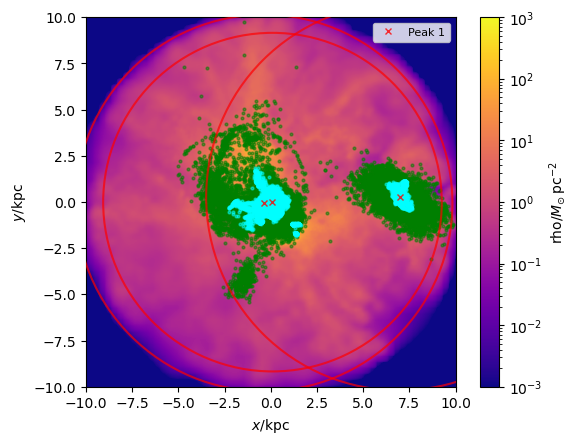

In [24]:
sp = s[pynbody.filt.Sphere(SimArray([rad], "kpc"), roughcen)].load_copy()
sp.physical_units()
sp['pos'] -= roughcen
rel2 = np.isin(sp.s['iord'], pids)
rel_tlim = np.isin(sp.s['iord'], pids_tlim)

# By default, will project down the x axis
pynbody.plot.sph.image(
    sp.g, qty="rho", units="Msol pc**-2", width=rad*2,
    vmin=10**-3, vmax=10**3, cmap="plasma"
)
#fig, ax = plt.subplots(figsize=(10, 10))

plt.plot(
        sp.s['pos'][:, 0], sp.s['pos'][:, 1],
        markersize=1.0, color='grey', marker='o', alpha=0.1, linestyle='none')
plt.plot(
    sp.s['pos'][rel2][:, 0], sp.s['pos'][rel2][:, 1],
    markersize=2.0, color='green', marker='o', alpha=0.5, linestyle='none')
if np.sum(rel_tlim) > 0:
    plt.plot(
        sp.s['pos'][rel_tlim][:, 0], sp.s['pos'][rel_tlim][:, 1],
        markersize=2.0, color='cyan', marker='o', alpha=0.5, linestyle='none')
for i, (x_peak, y_peak, z_peak, peak_rad) in enumerate(zip(final_x, final_y, final_z, peak_radius)):
    plt.plot(
        x_peak-roughcen[0], y_peak-roughcen[1],
        markersize=5.0, color='red', marker='x', alpha=0.8, linestyle='none',
        label=f'Peak {i+1}' if i == 0 else None
    )
    circle = plt.Circle(
        (x_peak-roughcen[0], y_peak-roughcen[1]), peak_rad,
        edgecolor='red', facecolor='none', lw=1.5, alpha=0.7, zorder=10
    )
    plt.gca().add_patch(circle)
    print(f"Plotted peak {i+1} at ({x_peak-roughcen[0]:.3f}, {y_peak-roughcen[1]:.3f}) with radius {peak_rad:.3f} kpc")

plt.xlim(-rad, rad)
plt.ylim(-rad, rad)
plt.legend(loc='upper right', fontsize=8)
plt.show()

### Matching with Dark Matter Halos

The following section is useful if you are trying to associate stars with a different dark matter halo

Peak 0 at (-1542.100, 1383.569, -3184.005) kpc:
  Found 2450 dark matter particles within 0.5 kpc


  Halo group distribution:
    Halo 0: 2 particles (0.1%)
    Halo 1: 3 particles (0.1%)
    Halo 2: 6 particles (0.2%)
    Halo 31: 2439 particles (99.6%)


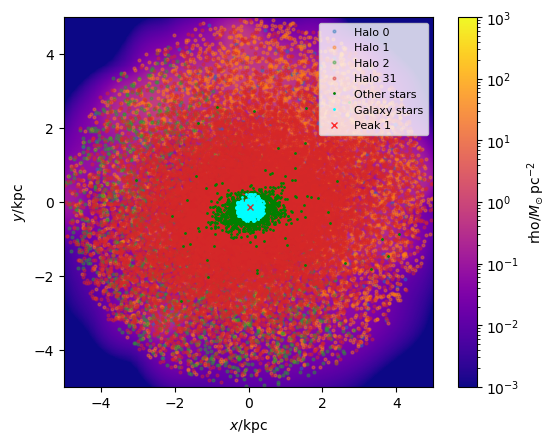


Peak 1 at (-1542.322, 1383.569, -3184.069) kpc:
  Found 2286 dark matter particles within 0.5 kpc
  Halo group distribution:
    Halo 0: 1 particles (0.0%)
    Halo 1: 2 particles (0.1%)
    Halo 2: 8 particles (0.3%)
    Halo 31: 2275 particles (99.5%)


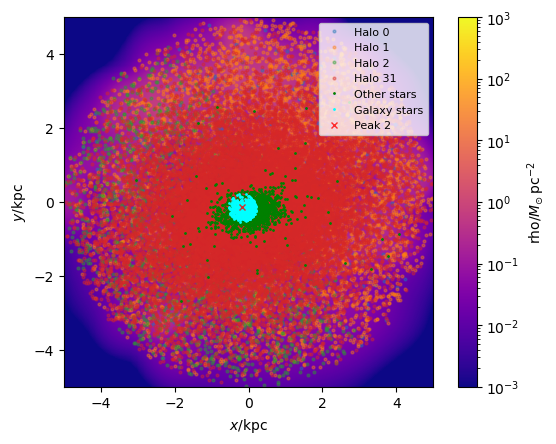



Total peaks processed: 2
Non-empty selections: 2


In [143]:
# Create spherical filters to select dark matter particles within buffer radius of each peak
dark_matter_selections = []
grp_histograms = []
filter_rad = 0.5 # Radius to select dark matter particles around each peak (in kpc). 
                # You can adjust this based on how tightly clustered the stars are around the peaks. The goal is to capture the dark matter halo associated with each stellar peak without including too much of the surrounding area.
galaxy_rad = 0.4 # Radius that must contain all the star particles for a given galaxy (in kpc)

for i, (x_peak, y_peak, z_peak) in enumerate(zip(final_x, final_y, final_z)):
    # Skip if any coordinate is NaN
    if np.isnan(x_peak) or np.isnan(y_peak) or np.isnan(z_peak):
        print(f"Skipping peak {i} due to NaN coordinates")
        dark_matter_selections.append(None)
        grp_histograms.append(None)
        continue
    
    # Create center position (need to add back roughcen offset)
    peak_center = SimArray([x_peak, y_peak, z_peak], units='kpc')
    
    # Create spherical filter for dark matter particles
    sphere_filter = pynbody.filt.Sphere(SimArray([filter_rad], "kpc"), peak_center)
    dm_particles = s.d[sphere_filter]

    sphere_filter_galaxy = pynbody.filt.Sphere(SimArray([galaxy_rad], "kpc"), peak_center)
    star_particles = s.s[sphere_filter_galaxy]
    
    print(f"Peak {i} at ({x_peak:.3f}, {y_peak:.3f}, {z_peak:.3f}) kpc:")
    print(f"  Found {len(dm_particles)} dark matter particles within {filter_rad} kpc")
    
    # Get histogram of amiga.grp values for these dark matter particles
    if len(dm_particles) > 0:
        grp_values = dm_particles['amiga.grp']
        unique_grps, grp_counts = np.unique(grp_values, return_counts=True)
        print(f"  Halo group distribution:")
        for grp, count in zip(unique_grps, grp_counts):
            print(f"    Halo {grp}: {count} particles ({100*count/len(dm_particles):.1f}%)")
        grp_histograms.append((unique_grps, grp_counts))
    else:
        grp_histograms.append(None)
    
    dark_matter_selections.append(dm_particles)

    pynbody.plot.sph.image(
        sp.g, qty="rho", units="Msol pc**-2", width=rad*2,
        vmin=10**-3, vmax=10**3, cmap="plasma"
    )
    #fig, ax = plt.subplots(figsize=(10, 10))
    for halo in unique_grps:
        halo_particles = sp.d[sp.d['amiga.grp'] == halo]
        plt.plot(
            halo_particles['pos'][:, 0], halo_particles['pos'][:, 1],
            markersize=2.0, marker='o', alpha=0.4, linestyle='none',
            label=f'Halo {halo}' 
        )
    plt.plot(
        sp.s['pos'][:, 0], sp.s['pos'][:, 1],
        markersize=1.0, color='green', marker='o', alpha=1, linestyle='none',
        label='Other stars'
    )
    plt.plot(
        star_particles['pos'][:, 0] - roughcen[0], star_particles['pos'][:, 1] - roughcen[1],
        markersize=1.0, color='cyan', marker='o', alpha=1, linestyle='none',
        label='Galaxy stars'
    )
    plt.plot(
        x_peak-roughcen[0], y_peak-roughcen[1],
        markersize=5.0, color='red', marker='x', alpha=0.8, linestyle='none',
        label=f'Peak {i+1}'
    )
    plt.xlim(-rad, rad)
    plt.ylim(-rad, rad)
    plt.legend(loc='upper right', fontsize=8)
    plt.show()
    print()

print(f"\nTotal peaks processed: {len(dark_matter_selections)}")
print(f"Non-empty selections: {sum(1 for sel in dark_matter_selections if sel is not None and len(sel) > 0)}")

In [144]:
# For a given peak (representing a galaxy), find the list of iords (fst) so that they can be written to an array to
# be reassigned to a new host_ID. After this cell is run, run the cell under "Write out" to write the "*.npy" file.

# You may want to assign a different host_ID than what is shown here.
# Be careful that galaxy_rad is selecting all the stars in the galaxy and only the stars in the galaxy

i = 0 # Index of peak
x_peak, y_peak, z_peak = final_x[i], final_y[i], final_z[i]
# Create center position (need to add back roughcen offset)
peak_center = SimArray([x_peak, y_peak, z_peak], units='kpc')
sphere_filter_galaxy = pynbody.filt.Sphere(SimArray([galaxy_rad], "kpc"), peak_center)
fst = s.s[sphere_filter_galaxy]['iord']

sphere_filter = pynbody.filt.Sphere(SimArray([filter_rad], "kpc"), peak_center)
dm_particles = s.d[sphere_filter]

# Get histogram of amiga.grp values for these dark matter particles
if len(dm_particles) > 0:
    grp_values = dm_particles['amiga.grp']
    unique_grps, grp_counts = np.unique(grp_values, return_counts=True)
    print(f"  Halo group distribution:")
    for grp, count in zip(unique_grps, grp_counts):
        print(f"    Halo {grp}: {count} particles ({100*count/len(dm_particles):.1f}%)")
    grp_histograms.append((unique_grps, grp_counts))
else:
    grp_histograms.append(None)

dark_matter_selections.append(dm_particles)

nh = str(st).zfill(4) + '_' + str(unique_grps[np.argmax(grp_counts)]) 
print(nh)
print(fst)# name of halo for this peak


  Halo group distribution:
    Halo 0: 2 particles (0.1%)
    Halo 1: 3 particles (0.1%)
    Halo 2: 6 particles (0.2%)
    Halo 31: 2439 particles (99.6%)
3648_31
[41652176 41652210 41704652 41706502 41706503 41706602 41708776 41709955
 41710685 41710686 41710687 41710688 41710917 41713967 41714152 41714224
 41714466 41714523 41715698 41715705 41716077 41716147 41716252 41716341
 41716381 41716455 41716475 41716557 41716613 41716911 41716912 41717484
 41717834 41717943 41718342 41718413 41718480 41718685 41718809 41721093
 41722306 41722307 41722839 41722841 41723144 41723943 41724034 41725349
 41725656 41725657 41726937 41727768 41728220 41728550 41728712 41728713
 41728714 41731586 41733031 41737015 41737822 41738196 41738197 41738754
 41741100 41741986 41742795 41744820 41744821 41745198 41745264 41745308
 41745364 41745464 41745644 41746018 41746251 41746252 41746330 41746331
 41746332 41746416 41746557 41746697 41747147 41747375 41750501 41751052
 41752285 41758836 41760451 41760

figure out halo ids are assigned
find what amiga assigns halos to
1. figure what halo currently in
2. figure out halo assignments in anna's code

#### Run

### Routine for Visualizing and Saving Every Star-Forming Halo

In [ ]:
sim_db = db.get_simulation(ss_dir)
all_timesteps = db.get_simulation(ss_dir).timesteps
halos_stars_dict = {}
for timestep in all_timesteps:
    print('Processing timestep:', timestep.extension[-6:])
    halos_stars_dict[timestep.extension[-6:]] = [h for h in timestep.halos.all() if h.NStar > 0]

total_halos = 0
for i, timestep in enumerate(all_timesteps):
    # print(timestep.extension[-6:])
    timestep = timestep.extension[-6:]
    halos = halos_stars_dict[timestep]
    print('\nFound {} halos in timestep {}'.format(len(halos), timestep))
    total_halos += len(halos)
    if mm:
        s = pynbody.load(sim_base + ss_dir + '.' + timestep 
                         + '/' + ss_dir + '.' + timestep)
    else:
        s = pynbody.load(sim_base + sims + '.' + timestep)
    s.physical_units()

    st = int(timestep) # Which snapshot do you want to visualize these star particles at?
    if not i < 1:
        tslim = int(all_timesteps[i-1].extension[-6:])
        print('Found previous timestep:', tslim)
    else:
        tslim = 0 # What is the earliest snapshot that you want the star particles to have formed at?

    uplim = db.get_timestep("%" + timestep,sim=sim_db).time_gyr
    if tslim>0:
        lowlim = db.get_timestep("%" + all_timesteps[i-1].extension[-6:],sim=sim_db).time_gyr
    elif tslim == 0:
        lowlim = 0
    else:
        print ('Please rethink your lowlim value. It does not make sense.')

print('\nFound {} halos in total'.format(total_halos))

In [ ]:
total_halos = 0
# all_timesteps = all_timesteps[12:]
for i, timestep in enumerate(all_timesteps):
    # print(timestep.extension[-6:])
    timestep = timestep.extension[-6:]
    halos = halos_stars_dict[timestep]
    print('\nFound {} halos in timestep {}'.format(len(halos), timestep))
    total_halos += len(halos)
    if mm:
        s = pynbody.load(sim_base + ss_dir + '.' + timestep 
                         + '/' + ss_dir + '.' + timestep)
    else:
        s = pynbody.load(sim_base + sims + '.' + timestep)

    s.physical_units()

    st = int(timestep) # Which snapshot do you want to visualize these star particles at?
    if not i < 1:
        tslim = int(all_timesteps[i-1].extension[-6:])
        print('Found previous timestep:', tslim)
    else:
        tslim = 0 # What is the earliest snapshot that you want the star particles to have formed at?

    uplim = db.get_timestep("%" + timestep,sim=sim_db).time_gyr
    if tslim>0:
        lowlim = db.get_timestep("%" + all_timesteps[i-1].extension[-6:],sim=sim_db).time_gyr
    elif tslim == 0:
        lowlim = 0
    else:
        print ('Please rethink your lowlim value. It does not make sense.')

In [ ]:
import tqdm.auto as tqdm

pbar = tqdm.tqdm(total=total_halos, desc='Processing halos')
for i, timestep in enumerate(all_timesteps):
    # print(timestep.extension[-6:])
    timestep = timestep.extension[-6:]
    halos = halos_stars_dict[timestep]
    print('\nFound {} halos in timestep {}'.format(len(halos), timestep))
    if mm:
        s = pynbody.load(sim_base + ss_dir + '.' + timestep 
                         + '/' + ss_dir + '.' + timestep)
    else:
        s = pynbody.load(sim_base + sims + '.' + timestep)
    s.physical_units()

    st = int(timestep) # Which snapshot do you want to visualize these star particles at?
    if not i < 1:
        tslim = int(all_timesteps[i-1].extension[-6:])
        print('Found previous timestep:', tslim)
    else:
        tslim = 0 # What is the earliest snapshot that you want the star particles to have formed at?

    uplim = db.get_timestep("%" + timestep,sim=sim_db).time_gyr
    if tslim>0:
        lowlim = db.get_timestep("%" + all_timesteps[i-1].extension[-6:],sim=sim_db).time_gyr
    elif tslim == 0:
        lowlim = 0
    else:
        print ('Please rethink your lowlim value. It does not make sense.')

    for halo in halos:
        relhostid = np.array([str(st) + '_' + str(halo.halo_number)])
        print('relhostid = ', relhostid)
        # pids = partids[(np.isin(hostids,relhostid)) & (pct>lowlim) & (pct<uplim)]
        pids = partids[(np.isin(ph,halo.halo_number)) & (pct>lowlim) & (pct<uplim)]
        print ('Relevant particles:',len(pids)) # How many star particles will actually be highlighted?
        if len(pids) == 0:
            print('No relevant particles found. Skipping')
            pbar.update(1)
            continue
        # print ('Looking for: ', len(pids)) # Full number of relevant star particles in this snapshot.
                                       # Make sure you actually find all of them!
        # print(halo.all_properties)
        try:
            roughcen = halo['shrink_center']
        except:
            try:
                roughcen = pynbody.analysis.halo.shrink_sphere_center(h[halo.halo_number])
            except:
                roughcen = [halo['Xc'],halo['Yc'],halo['Zc']]   
        try:
            rad = halo['Rvir']
        except:
            rad = halo['max_radius']
        fst = HighlightParticlesMultiProjection(s,roughcen,rad=rad,
                                 haloplot=True, show_hs=True, 
                                 caption=relhostid[0],
                                 savefig=True, overwrite=True) # Have our first look
        # fst = HighlightParticles(s,roughcen,rad=15, projax='x',
        #                          haloplot=False, show_hs=True)
        # fst = HighlightParticles(s,roughcen,rad=15, projax='y',
        #                          haloplot=False, show_hs=True)
        # fst = HighlightParticles(s,roughcen,rad=15, projax='z',
        #                          haloplot=False, show_hs=True)
        pbar.update(1)
        #break
    #break

### Old Again

In [ ]:
fst2 = all0000[~np.isin(all0000, fst)]

NameError: name 'all0000' is not defined

In [ ]:
# Print out the main progenitors of this halo in case you end up needing to back up and center on it
# at an earlier snapshot (e.g., if it has already disrupted)
if ishalo == 0:
    thisid = 1
else:
    thisid = ishalo
hti,sti = sim[dbind][thisid].calculate_for_progenitors('halo_number()','step_path()')
for sv,hv in zip(sti,hti):
    print (sv,hv)

r749.romulus25.3072g1HsbBH/r749.romulus25.3072g1HsbBH.000384/r749.romulus25.3072g1HsbBH.000384 1
r749.romulus25.3072g1HsbBH/r749.romulus25.3072g1HsbBH.000345/r749.romulus25.3072g1HsbBH.000345 1
r749.romulus25.3072g1HsbBH/r749.romulus25.3072g1HsbBH.000288/r749.romulus25.3072g1HsbBH.000288 1
r749.romulus25.3072g1HsbBH/r749.romulus25.3072g1HsbBH.000273/r749.romulus25.3072g1HsbBH.000273 1
r749.romulus25.3072g1HsbBH/r749.romulus25.3072g1HsbBH.000192/r749.romulus25.3072g1HsbBH.000192 1
r749.romulus25.3072g1HsbBH/r749.romulus25.3072g1HsbBH.000186/r749.romulus25.3072g1HsbBH.000186 1
r749.romulus25.3072g1HsbBH/r749.romulus25.3072g1HsbBH.000136/r749.romulus25.3072g1HsbBH.000136 1
r749.romulus25.3072g1HsbBH/r749.romulus25.3072g1HsbBH.000105/r749.romulus25.3072g1HsbBH.000105 1
r749.romulus25.3072g1HsbBH/r749.romulus25.3072g1HsbBH.000096/r749.romulus25.3072g1HsbBH.000096 1


### What follows is a hodgepodge of methods for spotting errant star particles and identifying their correct hosts + a cell that saves a list of particles to a numpy file as an input for FixHostIDs. I typically cycle through these in no particular order.

In [ ]:
# Less necessary for the MMs, but helpful for larger sims: will ding when it hits this point, as this 
# is where the standard initial pass ends and that can take a while
wave = np.sin(1.4*np.pi*400*np.arange(0.5*10000)/10000)
Audio(wave, rate=10000, autoplay=True)

In [ ]:
print (alskdfj) # This is really just a silly way of adding a break

NameError: name 'alskdfj' is not defined

In [25]:
# Create an empty list to contain the IDs of the relevant particles that you've found. 
#     You can add to this list as you find more particles by looking at the region from different angles.

inst = np.array([],dtype=int) # A list to contain the IDs of the relevant particles that you've found

82340 relevant stars found
Could not process halo 1: 'shrink_center'
Could not process halo 2: 'shrink_center'
Could not process halo 3: 'shrink_center'
Could not process halo 4: 'shrink_center'
Could not process halo 5: 'shrink_center'
Could not process halo 6: 'shrink_center'
Could not process halo 7: 'shrink_center'
Could not process halo 8: 'shrink_center'
Could not process halo 9: 'shrink_center'
Could not process halo 10: 'shrink_center'
Could not process halo 11: 'shrink_center'
Could not process halo 13: 'shrink_center'
Could not process halo 14: 'shrink_center'
Could not process halo 15: 'shrink_center'
Could not process halo 16: 'shrink_center'
Could not process halo 30: 'shrink_center'
Could not process halo 33: 'shrink_center'
Could not process halo 36: 'shrink_center'
Could not process halo 39: 'shrink_center'
Could not process halo 96: 'shrink_center'
Could not process halo 144: 'shrink_center'
Could not process halo 169: 'shrink_center'
Could not process halo 430: 'shrin

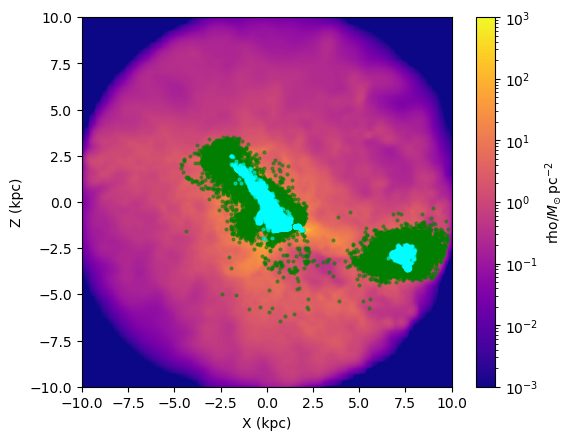

1056_43 3 0
1728_3 82340 27141


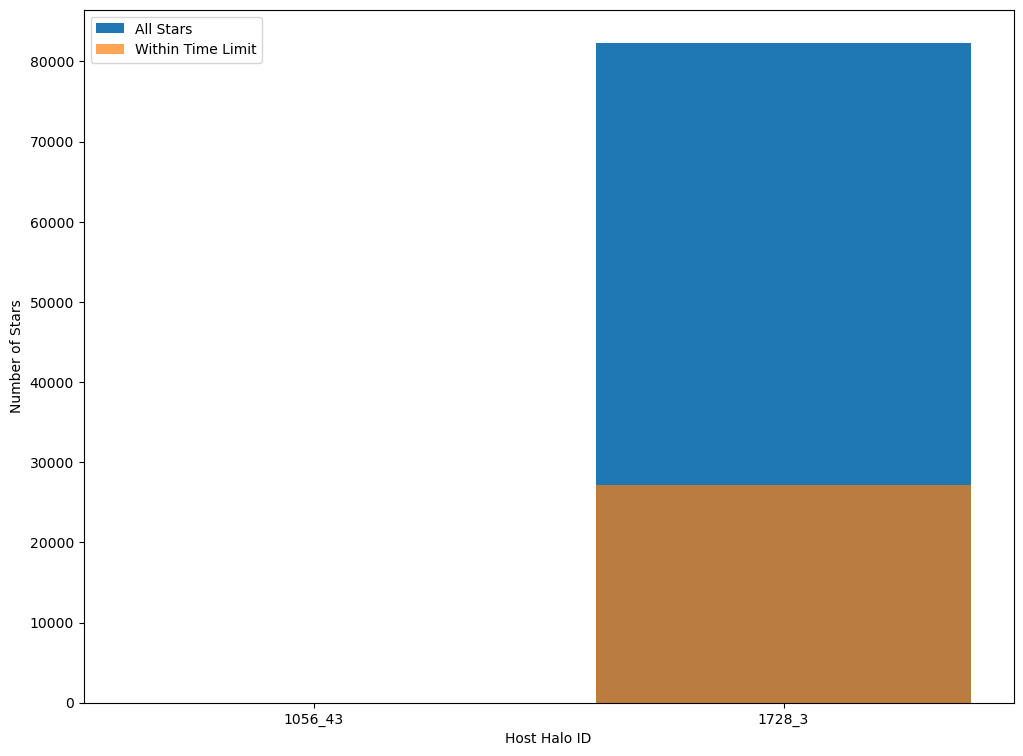

likely host: 1728_3
82340 relevant stars found
Could not process halo 1: 'shrink_center'
Could not process halo 2: 'shrink_center'
Could not process halo 3: 'shrink_center'
Could not process halo 4: 'shrink_center'
Could not process halo 5: 'shrink_center'
Could not process halo 6: 'shrink_center'
Could not process halo 7: 'shrink_center'
Could not process halo 8: 'shrink_center'
Could not process halo 9: 'shrink_center'
Could not process halo 10: 'shrink_center'
Could not process halo 11: 'shrink_center'
Could not process halo 13: 'shrink_center'
Could not process halo 14: 'shrink_center'
Could not process halo 15: 'shrink_center'
Could not process halo 16: 'shrink_center'
Could not process halo 30: 'shrink_center'
Could not process halo 33: 'shrink_center'
Could not process halo 36: 'shrink_center'
Could not process halo 39: 'shrink_center'
Could not process halo 96: 'shrink_center'
Could not process halo 144: 'shrink_center'
Could not process halo 169: 'shrink_center'
Could not proc

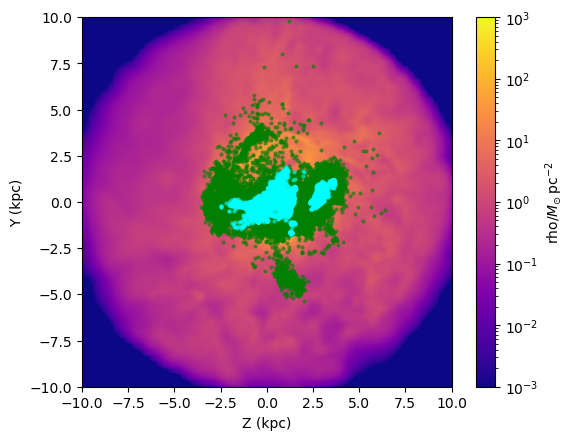

1056_43 3 0
1728_3 82340 27141


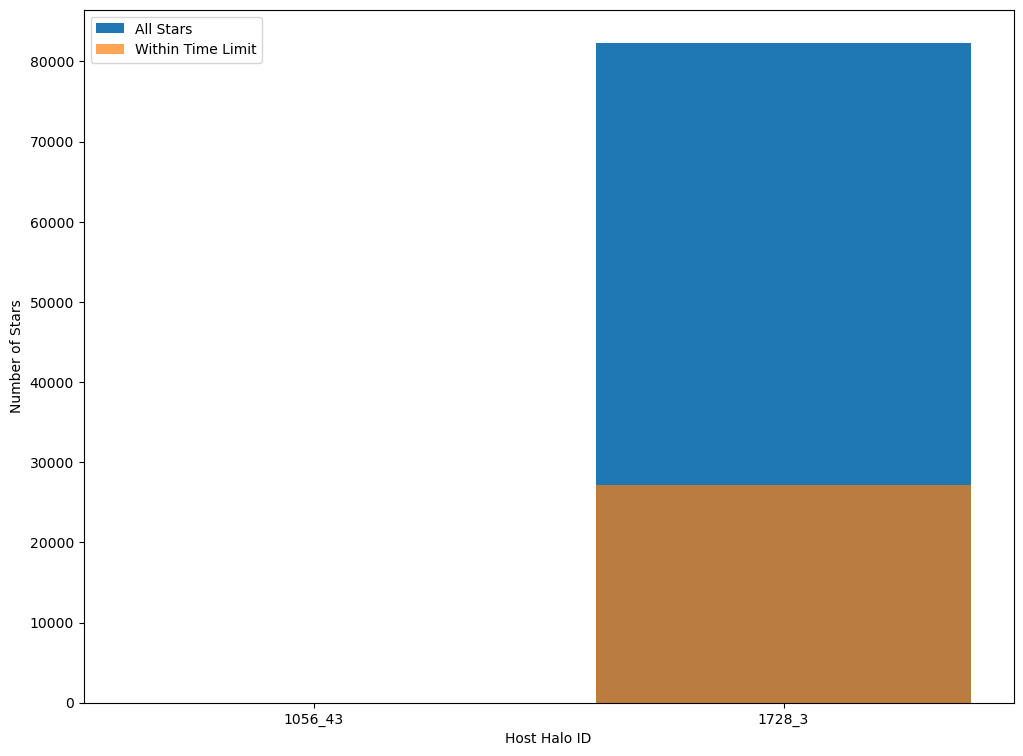

likely host: 1728_3
82340 relevant stars found
Could not process halo 1: 'shrink_center'
Could not process halo 2: 'shrink_center'
Could not process halo 3: 'shrink_center'
Could not process halo 4: 'shrink_center'
Could not process halo 5: 'shrink_center'
Could not process halo 6: 'shrink_center'
Could not process halo 7: 'shrink_center'
Could not process halo 8: 'shrink_center'
Could not process halo 9: 'shrink_center'
Could not process halo 10: 'shrink_center'
Could not process halo 11: 'shrink_center'
Could not process halo 13: 'shrink_center'
Could not process halo 14: 'shrink_center'
Could not process halo 15: 'shrink_center'
Could not process halo 16: 'shrink_center'
Could not process halo 30: 'shrink_center'
Could not process halo 33: 'shrink_center'
Could not process halo 36: 'shrink_center'
Could not process halo 39: 'shrink_center'
Could not process halo 96: 'shrink_center'
Could not process halo 144: 'shrink_center'
Could not process halo 169: 'shrink_center'
Could not proc

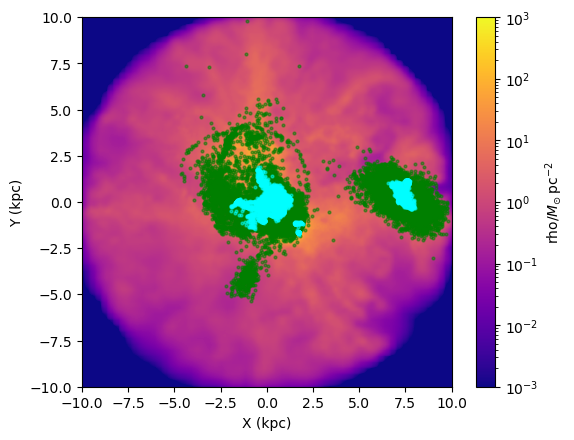

1056_43 3 0
1728_3 82340 27141


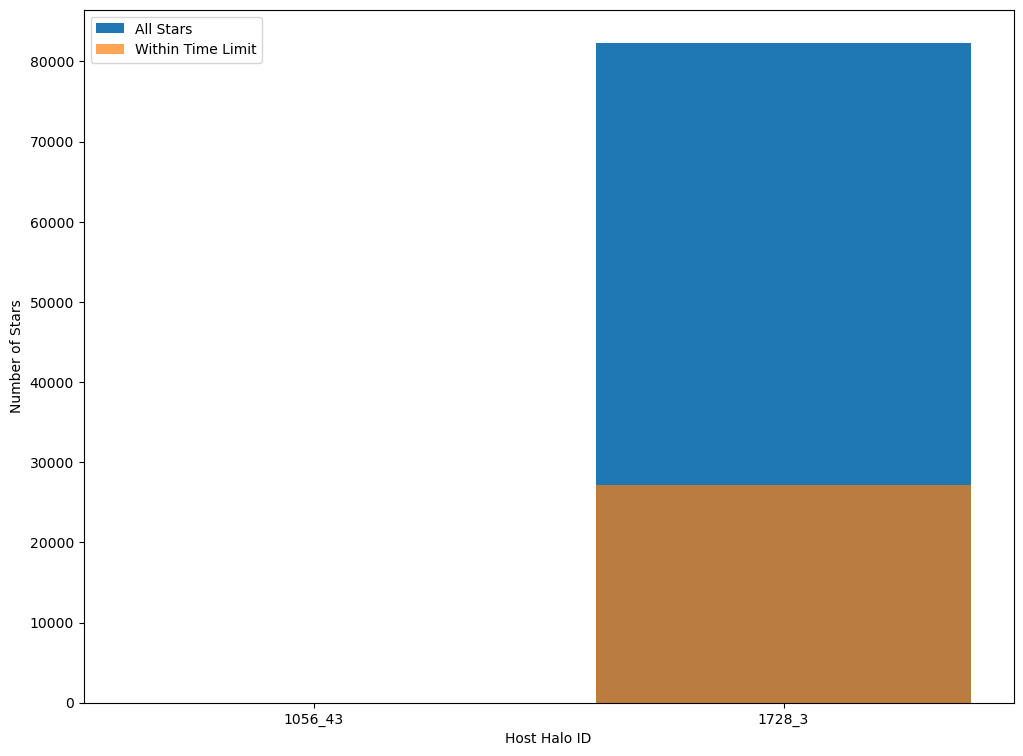

likely host: 1728_3
82340 relevant stars found
Could not process halo 1: 'shrink_center'
Could not process halo 2: 'shrink_center'
Could not process halo 3: 'shrink_center'
Could not process halo 4: 'shrink_center'
Could not process halo 5: 'shrink_center'
Could not process halo 6: 'shrink_center'
Could not process halo 7: 'shrink_center'
Could not process halo 8: 'shrink_center'
Could not process halo 9: 'shrink_center'
Could not process halo 10: 'shrink_center'
Could not process halo 11: 'shrink_center'
Could not process halo 13: 'shrink_center'
Could not process halo 14: 'shrink_center'
Could not process halo 15: 'shrink_center'
Could not process halo 16: 'shrink_center'
Could not process halo 30: 'shrink_center'
Could not process halo 33: 'shrink_center'
Could not process halo 36: 'shrink_center'
Could not process halo 39: 'shrink_center'
Could not process halo 96: 'shrink_center'
Could not process halo 144: 'shrink_center'
Could not process halo 169: 'shrink_center'
Could not proc

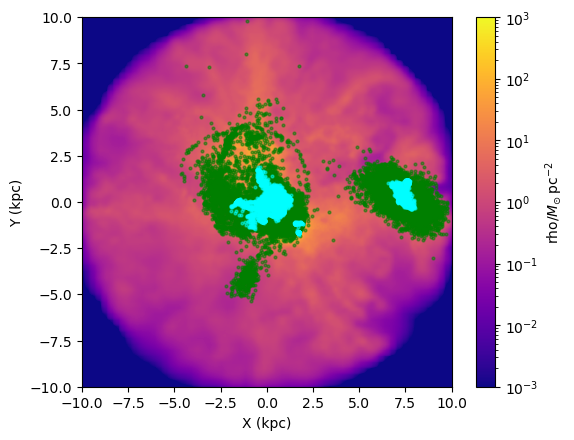

1056_43 3 0
1728_3 82340 27141


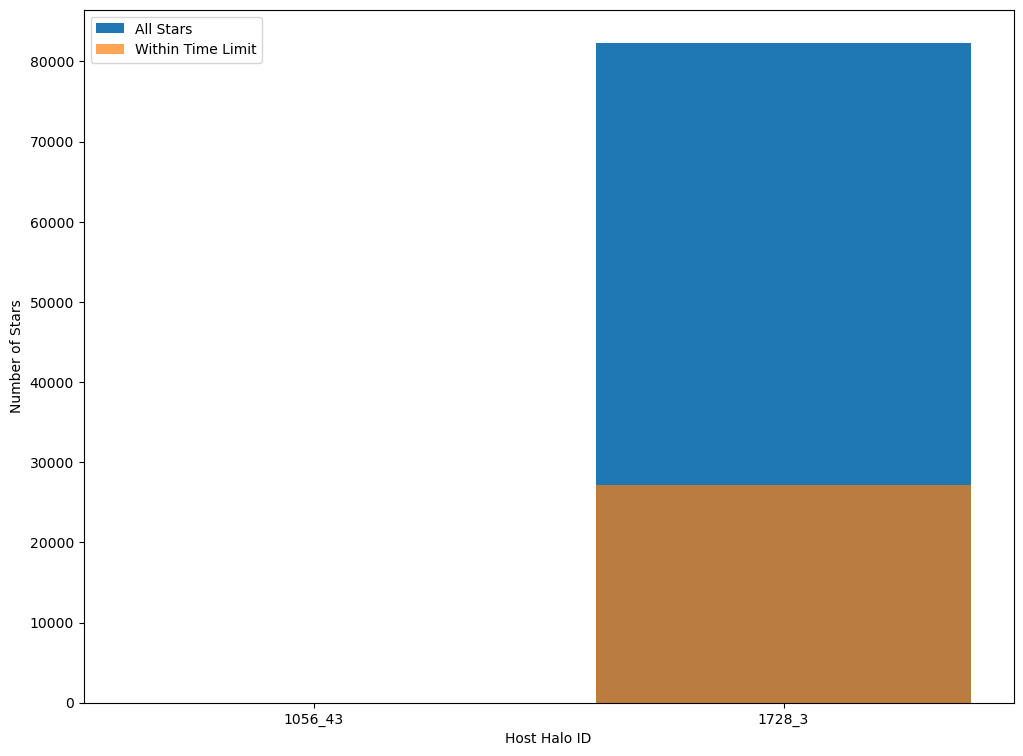

likely host: 1728_3
Number of star particles found in this region: 82344


In [26]:
# Look at the region from multiple angles to see if you can spot any star particles that look out of place.
# Adjust galrad as necessary. This also dings when it is done
galrad = valout*1.1 # 10.5
galrad = peak_radius[0] # Use multiple of standard deviation of halo stars around peak
galrad = 10
peak_i = 0
roughcen = np.array([final_x[peak_i], final_y[peak_i], final_z[peak_i]]) # You can adjust the center as needed based on what looks best in the visualizations. This is the median position of the star particles in the region, but you may want to adjust it based on how the star particles are distributed (e.g., if they look more centered around a different point or if there are outliers that are skewing the median).

fst = HighlightParticles(s,roughcen,rad=galrad,projax='y',show_hs=True)
fst = HighlightParticles(s,roughcen,rad=galrad,projax='x',show_hs=True)
# When ret='relstars', only the highlighted star particles (those formed after XXX and within the selected halo) will be returned, 
#.   When ret='all', all star particles in the sphere will be returned.
fst = HighlightParticles(s,roughcen,rad=galrad,projax='z',show_hs=True,ret='all') 
fst = HighlightParticles(s,roughcen,rad=galrad,projax='z',show_hs=True,ret='relstars_select') 
wave = np.sin(1.4*np.pi*400*np.arange(0.5*10000)/10000)
Audio(wave, rate=10000, autoplay=True)
print('Number of star particles found in this region:', len(fst))
if len(fst) < 100:
    print(fst)

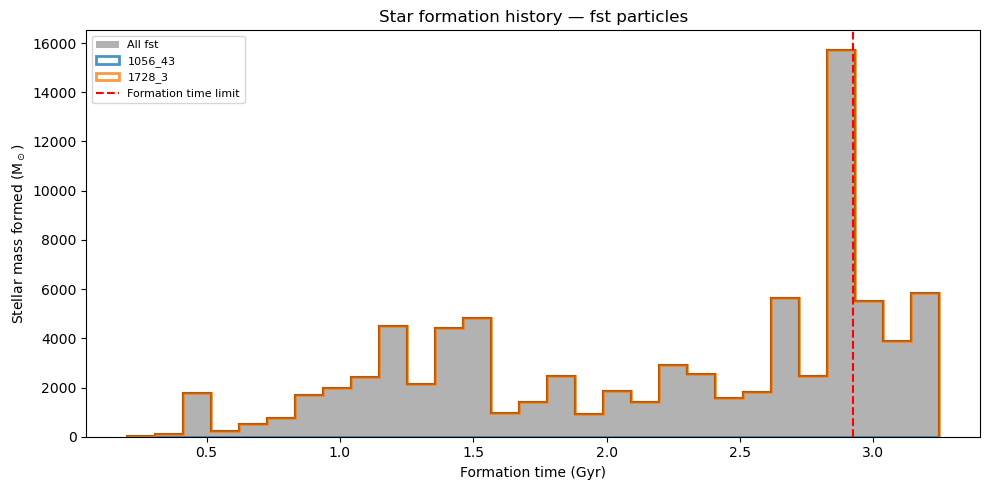

In [27]:
# Plot formation time histogram for stars in fst, weighted by formation mass,
# with per-halo breakdowns overlaid.

# Build iord -> massform lookup from the loaded snapshot
massform_arr = s.s['massform'].in_units('Msol')
mass_lookup = dict(zip(s.s['iord'], massform_arr))

# Pull formation times, host IDs, and masses for all fst particles from global arrays
fst_mask = np.isin(partids, fst)
fst_pct   = pct[fst_mask]
fst_ids   = partids[fst_mask]
fst_host  = hostids[fst_mask]
fst_masses = np.array([mass_lookup.get(iord, 0.0) for iord in fst_ids])

if len(fst_pct) == 0:
    print('No particles in fst to plot.')
else:
    bins = np.linspace(fst_pct.min(), fst_pct.max(), 30)

    fig, ax = plt.subplots(figsize=(10, 5))

    # Total fst histogram (filled, behind individual halos)
    ax.hist(fst_pct, bins=bins, 
            histtype='stepfilled', alpha=0.3, color='black', label='All fst') #weights=fst_masses,
    ax.hist(fst_pct, bins=bins, 
            histtype='step', lw=1.5, color='black') # weights=fst_masses,

    # Per-halo histograms
    for host in np.unique(fst_host):
        hmask = fst_host == host
        ax.hist(fst_pct[hmask], bins=bins, 
                histtype='step', lw=2, alpha=0.8, label=str(host)) # weights=fst_masses[hmask],

    ax.axvline(lowlim_select, color='red', linestyle='--', label='Formation time limit')
    ax.set_xlabel('Formation time (Gyr)')
    ax.set_ylabel(r'Stellar mass formed (M$_\odot$)')
    ax.set_title('Star formation history — fst particles')
    ax.legend(fontsize=8, loc='upper left')
    plt.tight_layout()
    plt.show()


In [28]:
# If lowlim_select is set, trim fst to only select star particles formed since that time, and print out how many that is.
if lowlim_select > 0:
    print('Now looking for star particles formed since {} Gyr ago'.format(lowlim_select))
    fst = partids[fst_mask][(pct[fst_mask]>=lowlim_select)]
    print('Number of star particles formed since {} Gyr ago: {}'.format(lowlim_select, len(fst)))
    

Now looking for star particles formed since 2.9237735456947953 Gyr ago
Number of star particles formed since 2.9237735456947953 Gyr ago: 17832


In [83]:
# Check off the particles you've found...
inst = np.concatenate((inst,np.array(fst,dtype=int))) # Put the particles whose IDs are currently stored in fst into your 
                                  # list of particles that you've found. 
inst = np.unique(inst) # Make sure there are no duplicates in your list of particles that you've found.
print("Total number of star particles found so far:", len(inst))

Total number of star particles found so far: 3215


Allow for iterative searching of unassigned particles

13755 stars still outstanding
16853 relevant stars found
Could not process halo 1: 'shrink_center'
Could not process halo 2: 'shrink_center'
Could not process halo 3: 'shrink_center'
Found 0 halos with stars
[]


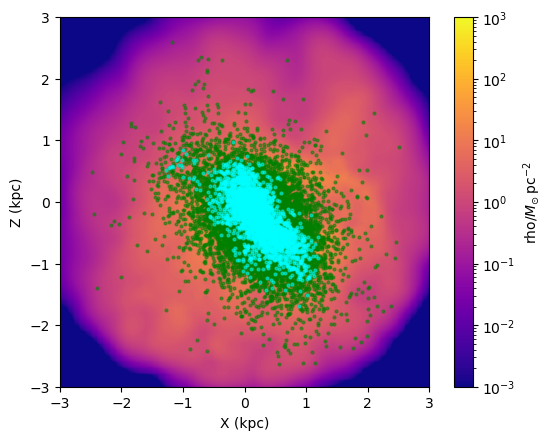

2496_3 16853 3020
2554_2 87 0


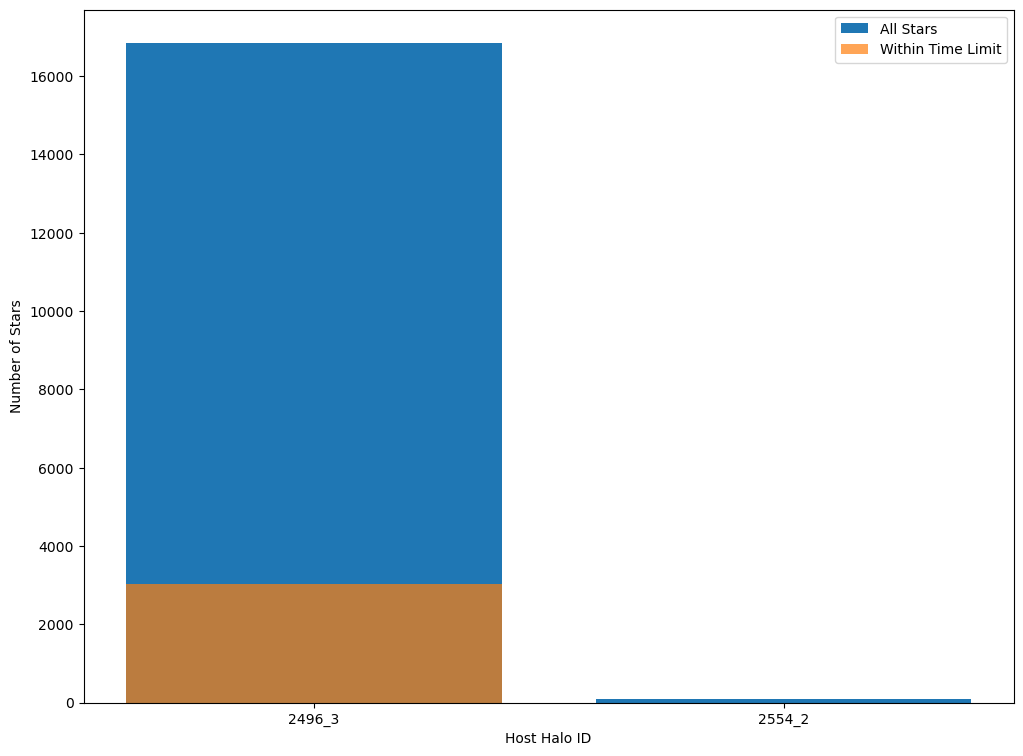

likely host: 2496_3


In [84]:
#...and center on different particles until you've found all of them. Re-run cell as necessary in combination with 
# those below it (and the one above it). Another one that dings.
stnotarr = pids[~np.isin(pids,inst)] # Make a list of relevant particles you haven't yet found
print (str(len(stnotarr))+' stars still outstanding')

# Find a particle from stnotarr that is actually present in s.s['iord']
roughcen = None
start = int(math.floor(len(stnotarr)/2))
for offset in range(len(stnotarr)):
    idx = (start + offset) % len(stnotarr)
    pos_match = s.s['pos'][s.s['iord'] == stnotarr[idx]]
    if len(pos_match) > 0:
        roughcen = pos_match[0]
        break
if roughcen is None:
    raise RuntimeError("None of the outstanding star IDs were found in s.s['iord']. "
                       "They may not be star particles in this snapshot.")

fst = HighlightParticles(s,roughcen,rad=3,projax='y',show_hs=True) 
wave = np.sin(1.4*np.pi*400*np.arange(0.5*10000)/10000)
Audio(wave, rate=10000, autoplay=True)


In [ ]:
# Are there any halos near our current center? Very occasionally helpful if a small halo formed a few stars but they were stripped
# before the next snapshot. It will print every halo within tol kpc along with its mass to help you sanity check. In my 
# experience, this is almost never helpful, but it's worth a shot if the previous methods have failed.
print (roughcen)
tol = 5 # distance in kpc out to which you want to search
curmin = 1000
for i in range(1,len(sim[dbind].halos[:])+1):
    curh = sim[dbind][i].finder_id
    dfh = np.linalg.norm(np.median(h[curh]['pos'],axis=0)-roughcen)
    if dfh<=tol:
        print (i,curh,dfh,np.log10(np.sum(h[curh]['mass'])))
    if dfh<curmin:
        curmin = dfh
print ('Best:',curmin)

In [ ]:
mask = hostids == relhostid[0]
partids_masked = partids[mask]

In [ ]:
print(len(partids_masked), 'particles found with host ID', relhostid)
print(len(fst), 'particles found in the highlighted region')

27974 particles found with host ID ['0480_2']
4201 particles found in the highlighted region


### Write out

In [29]:
nh = '1728_3' # The host_ID you want to reassign them to

In [30]:
# Save a list of star particle IDs to a numpy array so that you can use FixHostIDs to re-assign them
# Because you may end up with multiple lists of star particles that should be re-assigned to the same host,
# we'll check how many numpy files you already have in this format for this host and increment the file name to avoid
# overwriting a previous list (e.g., r492_0672_3_2.npy is the second list of star particles that should be re-assigned to
# host_ID '0672_3' in simulation r492).

hs = glob.glob(odir+sims+'_'+nh+'_*.npy')

maxind = 0
if len(hs)>0:
    for i in hs:
        val = int(str(i).split('_')[-1].split('.')[-2])
        if val>maxind:
            maxind = val
np.save(odir+sims+'_'+nh+'_'+str(maxind+1)+'.npy',fst)

In [31]:
hs = glob.glob(odir+sims+'_'+nh+'_*.npy')
print(hs)
# Copy or move the output files to your Datafiles directory so that you can use them in FixHostIDs. You can also do this manually if you prefer, but make sure to update the file paths in FixHostIDs accordingly.
print("mv /home/christenc/Code/python/NithunSelva_startrace/pynbody/stellarhalo_trace_aw/{}_*.npy \
   /home/christenc/Code/Datafiles/stellar_halos/{}/\n".format(halo_id, halo_id))

['/home/christenc/Code/python/NithunSelva_startrace/pynbody/stellarhalo_trace_aw/r615_1728_3_1.npy']
mv /home/christenc/Code/python/NithunSelva_startrace/pynbody/stellarhalo_trace_aw/r615_*.npy    /home/christenc/Code/Datafiles/stellar_halos/r615/



In [151]:
# fst

## 